ARTICLE NOTES TO TEST

- We observed a significant drop of the 1st order textural features “10th percentile” (p = 0.009), “median” (p = 0.01), and “minimum” (p <0.0001) after treatment
- &#9989; All parameters were tested for the normality by Kolmogorov–Smirnov test and Shapiro–Wilk test
- ❌ A Wilcoxon test was used to test the difference in textural features before and after treatment connected with -> To address the multiple comparisons, a Benjamin Hochberg correction was applied
- &#9989; We applied a z-transformation on all textural features to enable comparability of textural feature values

In [3]:
import pandas as pd
from scipy.stats import shapiro, kstest, wilcoxon
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [51]:
df = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df.head()

features_df = df.iloc[:, 1:]
features_df.head()

,n_lesions,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,...,gradient_gldm_LargeDependenceLowGrayLevelEmphasis,gradient_gldm_LowGrayLevelEmphasis,gradient_gldm_SmallDependenceEmphasis,gradient_gldm_SmallDependenceHighGrayLevelEmphasis,gradient_gldm_SmallDependenceLowGrayLevelEmphasis,gradient_ngtdm_Busyness,gradient_ngtdm_Coarseness,gradient_ngtdm_Complexity,gradient_ngtdm_Contrast,gradient_ngtdm_Strength
0,42,0.208989,0.090847,48.159211,530.112286,489.628282,477.609470,70.013470,524.164765,3558.334557,...,9.362924,0.188559,0.209187,14.160098,0.022200,4.583890,0.001057,1275.015695,0.027065,2.332194
1,26,0.312599,0.177995,56.369710,316.692125,312.249080,221.602910,62.017486,350.835395,9249.070315,...,28.594575,0.281659,0.126935,5.482893,0.015539,30.713151,0.000442,227.679082,0.031244,0.178511
2,8,0.212942,0.151533,36.779604,242.716318,120.025001,223.923365,26.654969,272.485527,1064.250852,...,9.860269,0.186676,0.205416,17.281903,0.019481,1.752884,0.003683,862.559969,0.048362,4.607406
3,54,0.159429,0.086400,43.732812,506.164698,448.831706,452.620461,83.059497,506.059601,29295.494225,...,34.494715,0.317299,0.156313,11.428918,0.015238,50.791713,0.000115,1226.057056,0.020648,0.360999
4,12,0.192710,0.149551,57.235029,382.711335,214.831665,320.170141,47.350217,373.626743,3274.072115,...,10.018471,0.174378,0.192016,16.347327,0.018704,7.015196,0.000999,731.506812,0.049377,1.028209


All parameters were tested for the normality by Kolmogorov–Smirnov test and Shapiro–Wilk test

In [22]:
# NORMALITY SHAPIRO-WILK
def split_by_normality(df):
    normal_features = []
    non_normal_features = []

    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        if df[col].dropna().shape[0] < 3:
            continue

        stat, p_val = shapiro(df[col].dropna())
        if p_val > 0.05:
            normal_features.append(col)
        else:
            non_normal_features.append(col)

    return normal_features, non_normal_features

normal_features_sw, non_normal_features_sw = split_by_normality(features_df)

print("-----SHAPIRO WILK TEST-----")
print("Normal features:", len(normal_features_sw))
print("Non-normal features:", len(non_normal_features_sw))
print()


# NORMALITY KOLMOGOROV-SMIRN
def split_by_ks_normality(features_df):
    normal_features = []
    non_normal_features = []

    numeric_cols = features_df.select_dtypes(include='number').columns

    for col in numeric_cols:
        data = features_df[col].dropna()
        if len(data) < 3:
            continue

        stat, p_val = kstest(data, 'norm', args=(data.mean(), data.std()))

        if p_val > 0.05:
            normal_features.append(col)
        else:
            non_normal_features.append(col)

    return normal_features, non_normal_features

normal_features_kw, non_normal_features_kw = split_by_ks_normality(features_df)

print("-----KOLMOGOROV WILK TEST-----")
print("Normal features:", len(normal_features_kw))
print("Non-normal features:", len(non_normal_features_kw))

-----SHAPIRO WILK TEST-----
Normal features: 71
Non-normal features: 130

-----KOLMOGOROV WILK TEST-----
Normal features: 152
Non-normal features: 49


Correlation analysis of image features

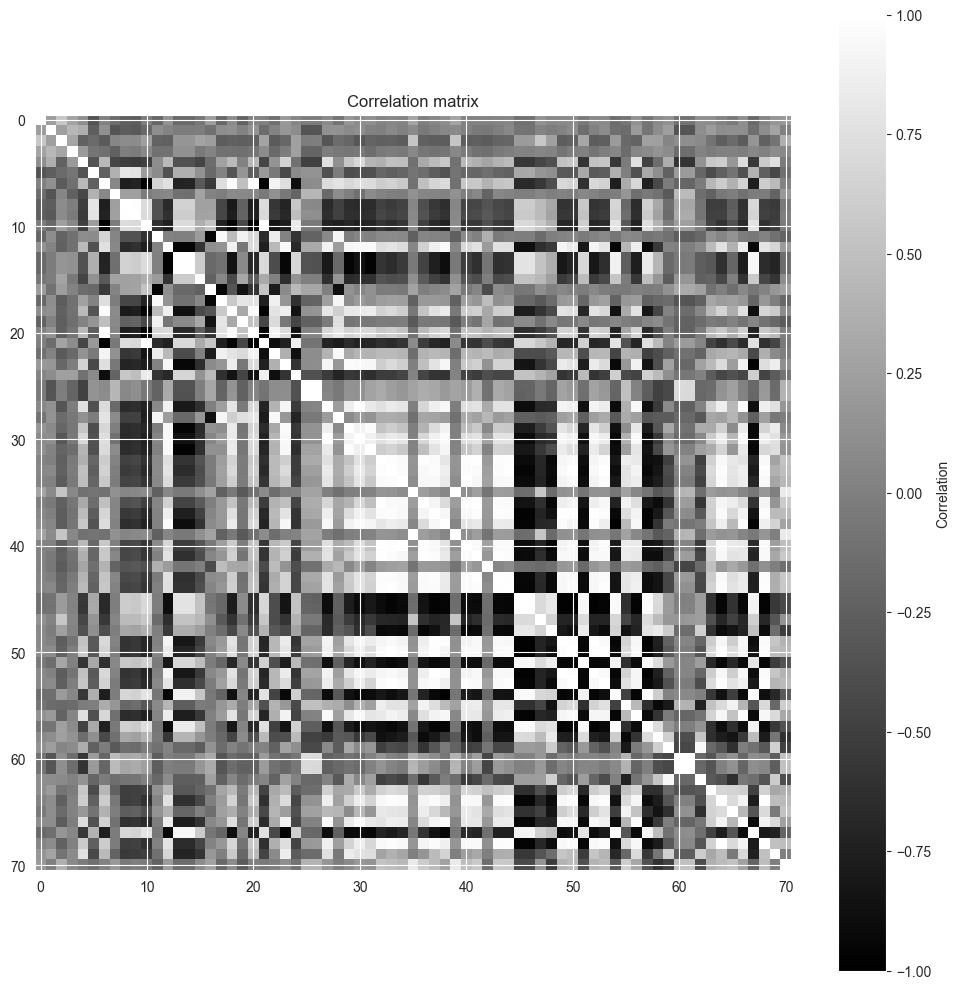

In [23]:
scaler = StandardScaler()
features = normal_features_sw   # normal_features_sw/non_normal_features_sw   normal_features_kw/non_normal_features_kw
method = "pearson"   # pearson/spearman/kendall

features_scaled = pd.DataFrame(scaler.fit_transform(features_df[features]), columns=features_df[features].columns, index=features_df[features].index)
corr_matrix = features_scaled.corr(method=method)

plt.figure(figsize=(10,10))
plt.imshow(corr_matrix, cmap='gray', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

❌ A Wilcoxon test was used to test the difference in textural features before and after treatment

- Can't be used for one patient on spine level (I need more values of same feature)
- Combine 10 patients with their follow up

In [52]:
before_treatment_patients = ["Myel_012", "Myel_018", "Myel_043", "Myel_052"]
after_treatment_patients = ["Myel_069", "Myel_047", "Myel_059", "Myel_070"]

before_df = df[df["patient"].isin(before_treatment_patients)].copy()
before_df['patient'] = pd.Categorical(before_df['patient'], categories=before_treatment_patients, ordered=True)
before_df = before_df.sort_values('patient').reset_index(drop=True)

after_df = df[df["patient"].isin(after_treatment_patients)].copy()
after_df['patient'] = pd.Categorical(after_df['patient'], categories=after_treatment_patients, ordered=True)
after_df = after_df.sort_values('patient').reset_index(drop=True)

results = []
for col in before_df.columns[1:]:

    stat, p = wilcoxon(before_df[col].values, after_df[col].values)
    results.append({'feature': col, 'statistic': stat, 'p_value': p})

results_df = pd.DataFrame(results).sort_values(by='p_value').reset_index(drop=True)
results_df['significant'] = results_df['p_value'] < 0.05

results_df

,feature,statistic,p_value,significant
0,original_shape_Maximum2DDiameterColumn,0.0,0.125,False
1,original_shape_SurfaceVolumeRatio,0.0,0.125,False
2,original_firstorder_Skewness,0.0,0.125,False
3,original_firstorder_Kurtosis,0.0,0.125,False
4,original_glszm_ZoneEntropy,0.0,0.125,False
...,...,...,...,...
196,gradient_glcm_MaximumProbability,5.0,1.000,False
197,gradient_glcm_SumAverage,5.0,1.000,False
198,gradient_glrlm_LongRunHighGrayLevelEmphasis,5.0,1.000,False
199,gradient_glrlm_RunEntropy,5.0,1.000,False


In [24]:
# COMPARISON OF DIFFERENCES BEFORE AND AFTER TREATMENT
scaler = StandardScaler()
df = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
numeric_cols = df.select_dtypes(include='number').columns
df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=df[numeric_cols].columns, index=df[numeric_cols].index)

before_treatment = df_scaled[df['patient'] == "Myel_012"]
after_treatment = df_scaled[df['patient'] == "Myel_069"]

diff = (before_treatment.iloc[0] - after_treatment.iloc[0]).abs()
diff_df = pd.DataFrame({"feature": diff.index, "difference": diff.values})
diff_df = diff_df.sort_values(by="difference", ascending=False).reset_index(drop=True)
# diff_df.head(20)
diff_df

,feature,difference
0,original_shape_Maximum2DDiameterSlice,3.093128
1,gradient_glszm_GrayLevelNonUniformityNormalized,3.008725
2,original_glszm_ZonePercentage,2.312539
3,original_gldm_SmallDependenceEmphasis,2.306469
4,gradient_glcm_Idmn,2.263402
...,...,...
196,original_glszm_ZoneVariance,0.025542
197,original_glszm_LargeAreaHighGrayLevelEmphasis,0.016859
198,gradient_gldm_LargeDependenceHighGrayLevelEmph...,0.015413
199,gradient_firstorder_TotalEnergy,0.002686
